In [168]:
# importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [169]:
df =  pd.read_csv('dataset_A_training.csv')
df

,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4751,4752,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Rent,Unemployed,"MSA, Not Principle City",0.0,0.0,NaN,0
4752,4753,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Female,NaN,Not Married,Rent,Not in Labor Force,Non-MSA,3.0,1.0,NaN,1
4753,4754,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,"MSA, Principle City",2.0,0.0,NaN,1
4754,4755,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN,1


In [170]:
# checking the variables information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

In [171]:
# Distribution of variabes
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in ['respondent_id', 'seasonal_vaccine']]
cat_cols = list(df.select_dtypes(include='object').columns)
TARGET   = 'seasonal_vaccine'

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Numeric features : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")


Dataset: 4,756 rows × 31 columns
Numeric features : 19
Categorical features: 10


**Exploratory Data Analysis**

In [172]:
%matplotlib inline

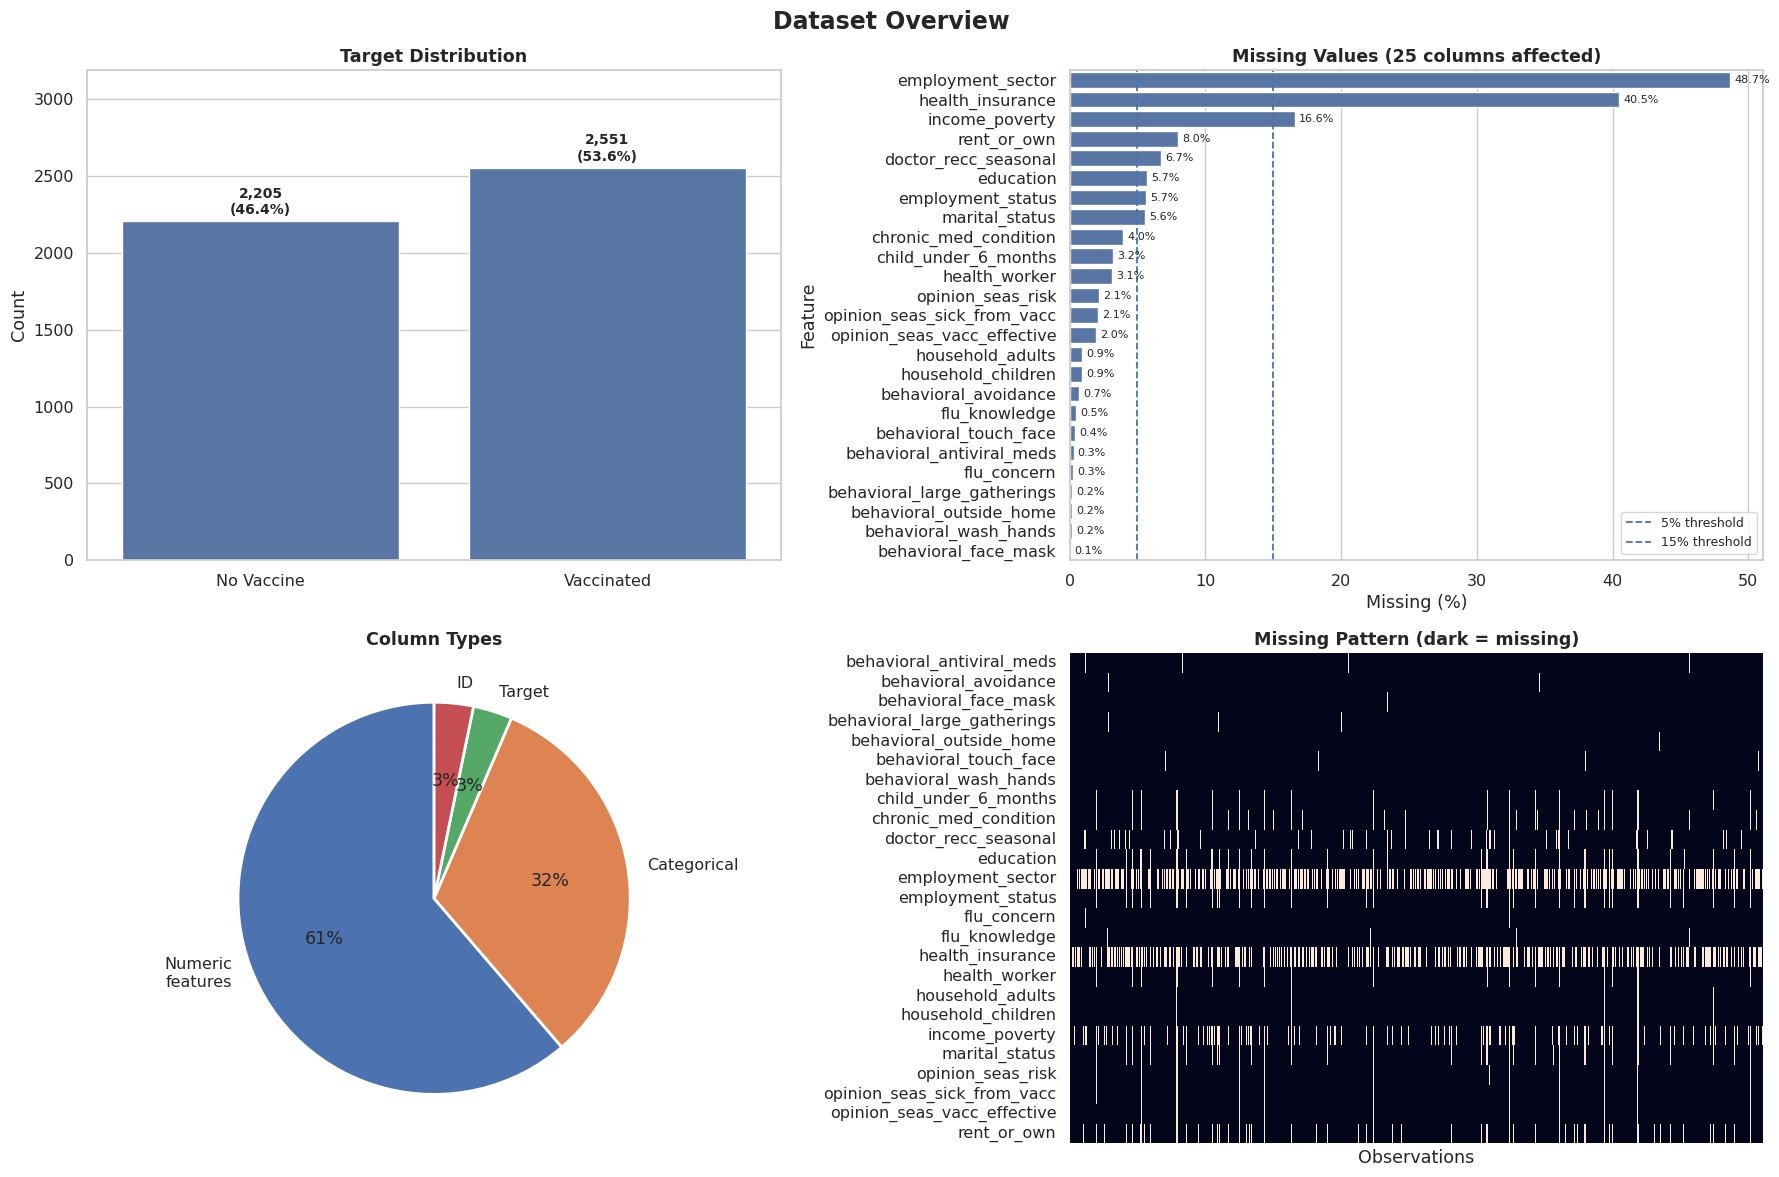

In [173]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Dataset Overview", fontsize=17, fontweight='bold')

# Create a 'vaccine_label' column for plotting
df['vaccine_label'] = df[TARGET].map({0: 'No Vaccine', 1: 'Vaccinated'})

# 1a Target distribution
sns.countplot(data=df, x='vaccine_label', order=['No Vaccine', 'Vaccinated'], ax=axes[0,0])
for p in axes[0,0].patches:
    axes[0,0].annotate(
        f'{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height() + 30),
        ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,0].set_title('Target Distribution', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Count')
axes[0,0].set_ylim(0, df[TARGET].value_counts().max() * 1.25)

# 1b Missing % bar
# Using TARGET instead of 'vaccine_label' in drop as TARGET is the original column name
miss = (df.drop(columns=['respondent_id', TARGET], errors='ignore')
          .isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0].reset_index()
miss.columns = ['Feature', 'Missing%']
sns.barplot(data=miss, y='Feature', x='Missing%', ax=axes[0,1])
axes[0,1].axvline(5,  linestyle='--', lw=1.3, label='5% threshold')
axes[0,1].axvline(15, linestyle='--', lw=1.3, label='15% threshold')
axes[0,1].set_title(f'Missing Values ({len(miss)} columns affected)', fontweight='bold')
axes[0,1].set_xlabel('Missing (%)')
axes[0,1].legend(fontsize=9)
for bar in axes[0,1].patches:
    w = bar.get_width()
    if w > 0:
        axes[0,1].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                       f'{w:.1f}%', va='center', fontsize=8)

# 1c Column-type pie
type_counts = {'Numeric\nfeatures': len(num_cols), 'Categorical': len(cat_cols),
               'Target': 1, 'ID': 1}
axes[1,0].pie(type_counts.values(), labels=type_counts.keys(),
              autopct='%1.0f%%', startangle=90,
              wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1,0].set_title('Column Types', fontweight='bold')

# 1d Missing heatmap pattern
# Using TARGET instead of 'vaccine_label' in difference
miss_cols = df.columns[df.isnull().any()].difference([TARGET]).tolist()
sns.heatmap(df[miss_cols].isnull().astype(int).T, ax=axes[1,1],
            cbar=False, yticklabels=miss_cols, xticklabels=False, linewidths=0)
axes[1,1].set_title('Missing Pattern (dark = missing)', fontweight='bold')
axes[1,1].set_xlabel('Observations')

plt.tight_layout()
display(fig)
plt.close()

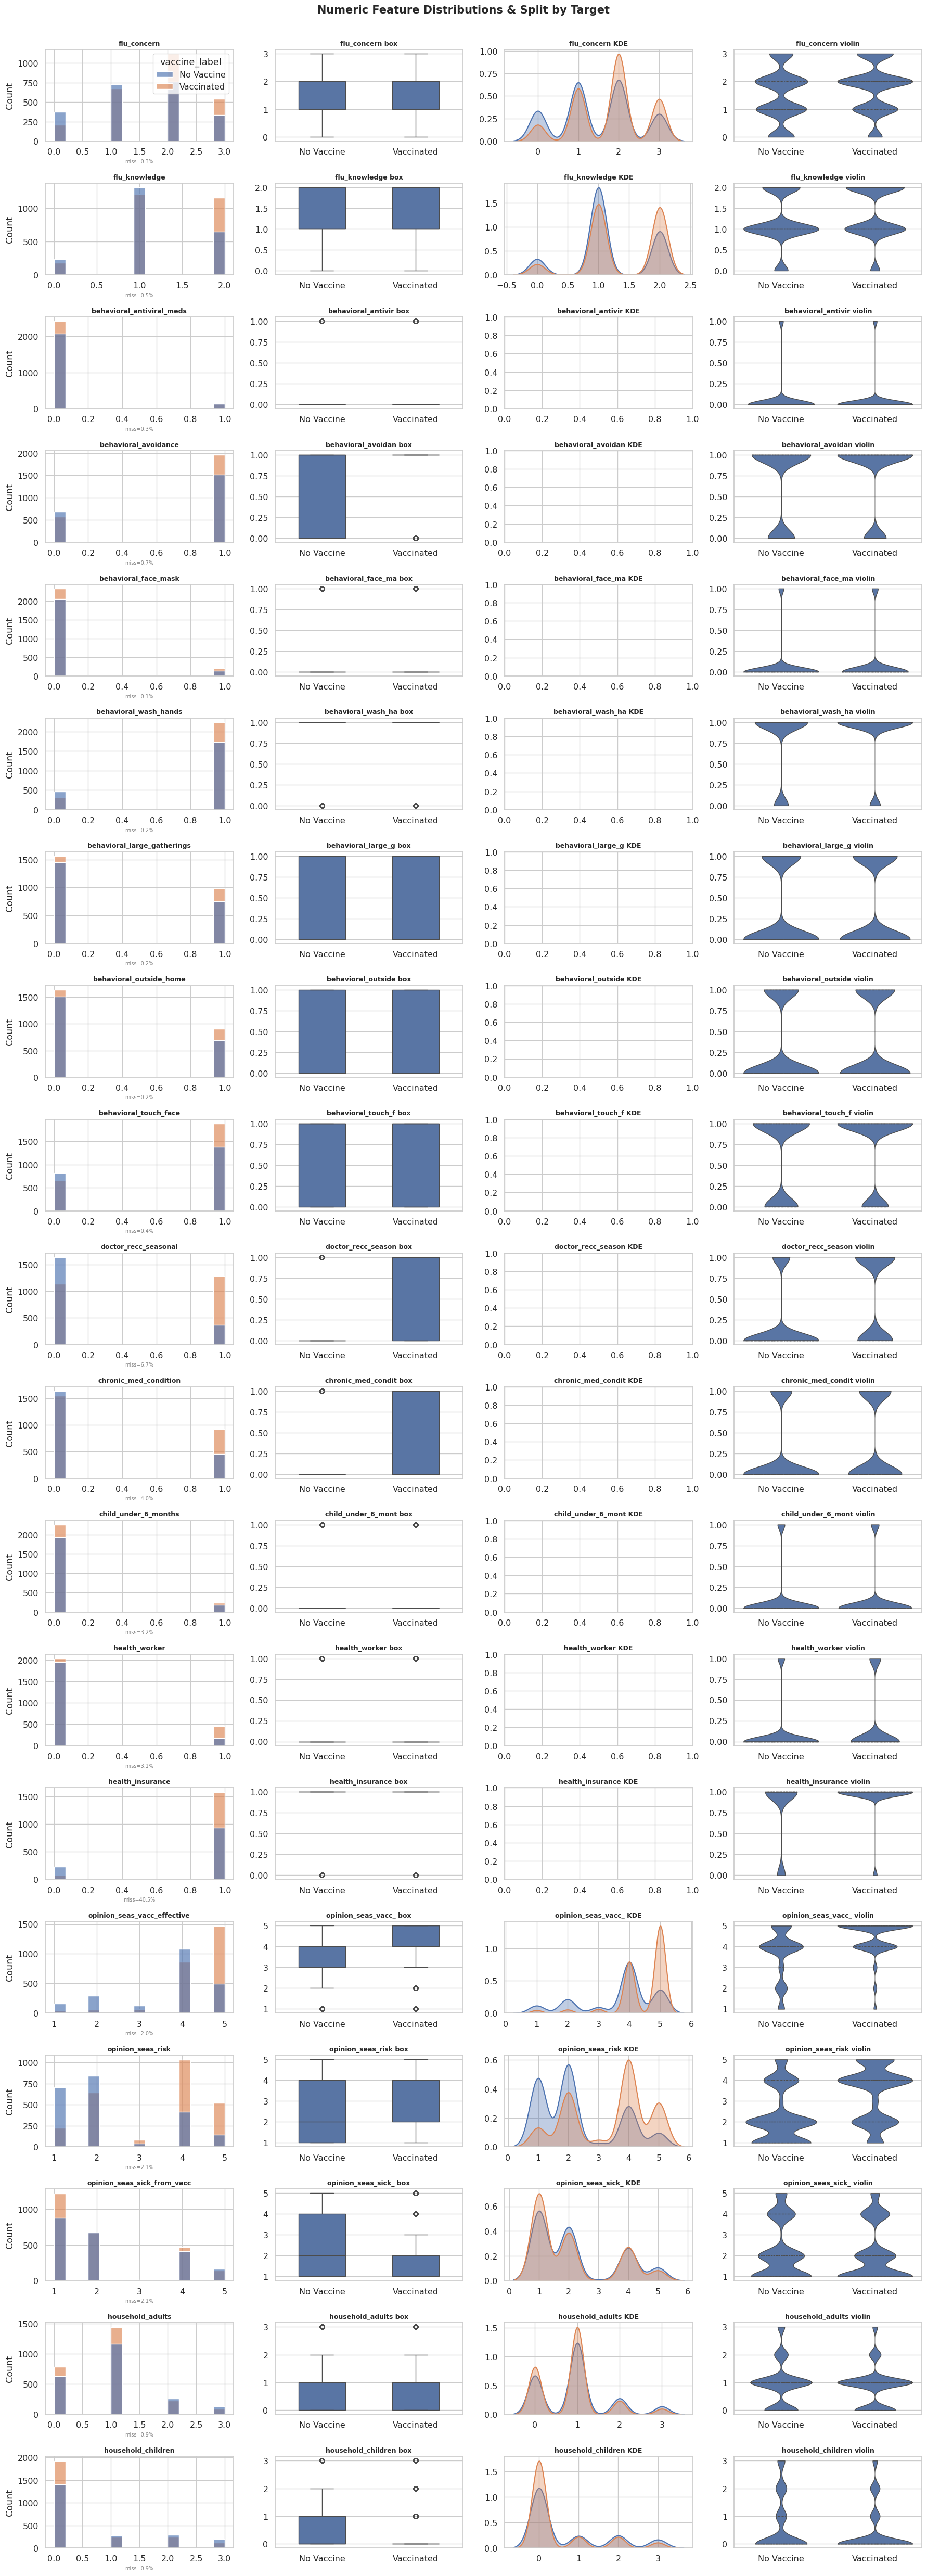

In [174]:
fig, axes = plt.subplots(len(num_cols), 4, figsize=(18, len(num_cols) * 2.6))
fig.suptitle("Numeric Feature Distributions & Split by Target",
             fontsize=15, fontweight='bold', y=1.002)

for i, col in enumerate(num_cols):
    tmp = df[[col, 'vaccine_label']].dropna()

    sns.histplot(data=tmp, x=col, hue='vaccine_label', bins=15,
                 alpha=0.65, ax=axes[i,0], legend=(i==0), edgecolor='white')
    axes[i,0].set_title(col, fontsize=9, fontweight='bold')
    axes[i,0].set_xlabel('')
    if df[col].isnull().mean() > 0:
        axes[i,0].set_xlabel(f"miss={df[col].isnull().mean()*100:.1f}%",
                             fontsize=7, color='gray')

    sns.boxplot(data=tmp, x='vaccine_label', y=col,
                order=['No Vaccine', 'Vaccinated'], ax=axes[i,1], width=0.5)
    axes[i,1].set_title(f'{col[:18]} box', fontsize=9, fontweight='bold')
    axes[i,1].set_xlabel('')
    axes[i,1].set_ylabel('')

    for lbl in ['No Vaccine', 'Vaccinated']:
        sub = tmp[tmp['vaccine_label'] == lbl][col]
        if sub.nunique() > 2:
            sns.kdeplot(sub, ax=axes[i,2], fill=True, alpha=0.35,
                        label=lbl, linewidth=1.5)
    axes[i,2].set_title(f'{col[:18]} KDE', fontsize=9, fontweight='bold')
    axes[i,2].set_xlabel('')
    axes[i,2].set_ylabel('')

    sns.violinplot(data=tmp, x='vaccine_label', y=col,
                   order=['No Vaccine', 'Vaccinated'], inner='quartile',
                   cut=0, ax=axes[i,3], linewidth=1)
    axes[i,3].set_title(f'{col[:18]} violin', fontsize=9, fontweight='bold')
    axes[i,3].set_xlabel('')
    axes[i,3].set_ylabel('')

plt.tight_layout()
display(fig)
plt.close()

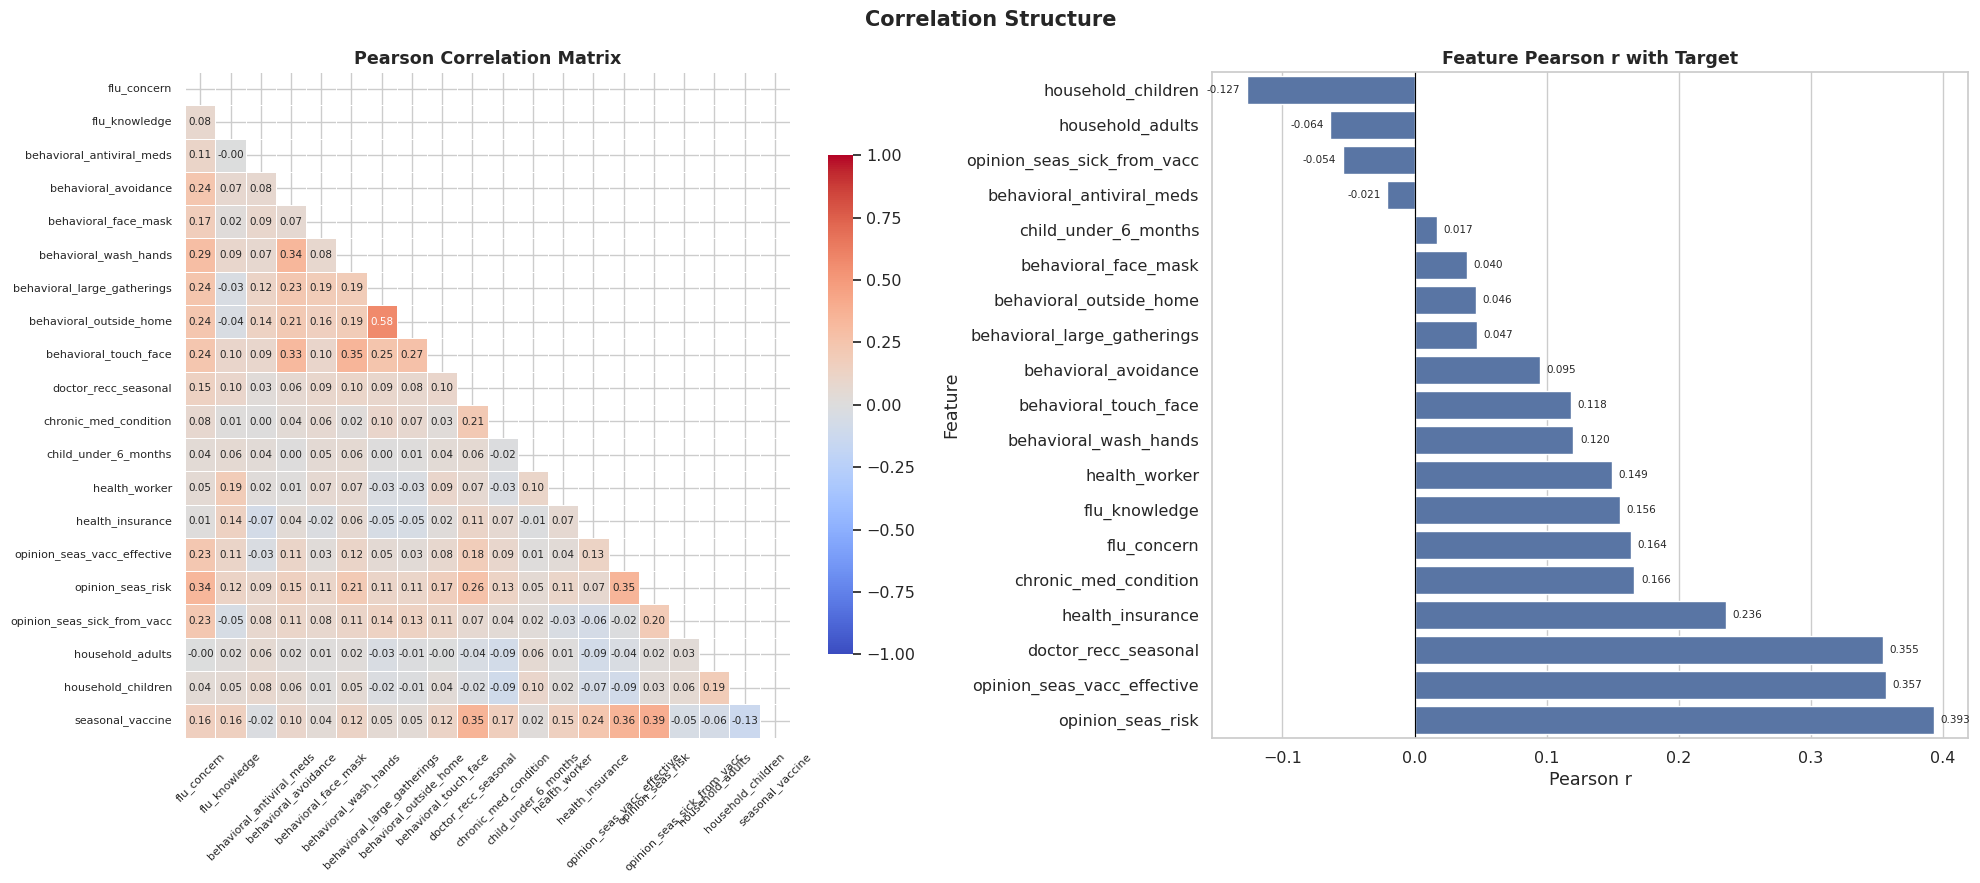

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("Correlation Structure", fontsize=15, fontweight='bold')

corr = df[num_cols + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0],
            cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7.5},
            linewidths=0.4, cbar_kws={'shrink': 0.75}, vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

tc = corr[TARGET].drop(TARGET).sort_values().reset_index()
tc.columns = ['Feature', 'r']
sns.barplot(data=tc, y='Feature', x='r', ax=axes[1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Pearson r with Target', fontweight='bold')
axes[1].set_xlabel('Pearson r')
for p in axes[1].patches:
    w = p.get_width()
    axes[1].text(w + (0.005 if w >= 0 else -0.005),
                 p.get_y() + p.get_height()/2,
                 f'{w:.3f}', va='center',
                 ha='left' if w >= 0 else 'right', fontsize=7.5)

plt.tight_layout()
display(fig)
plt.close()

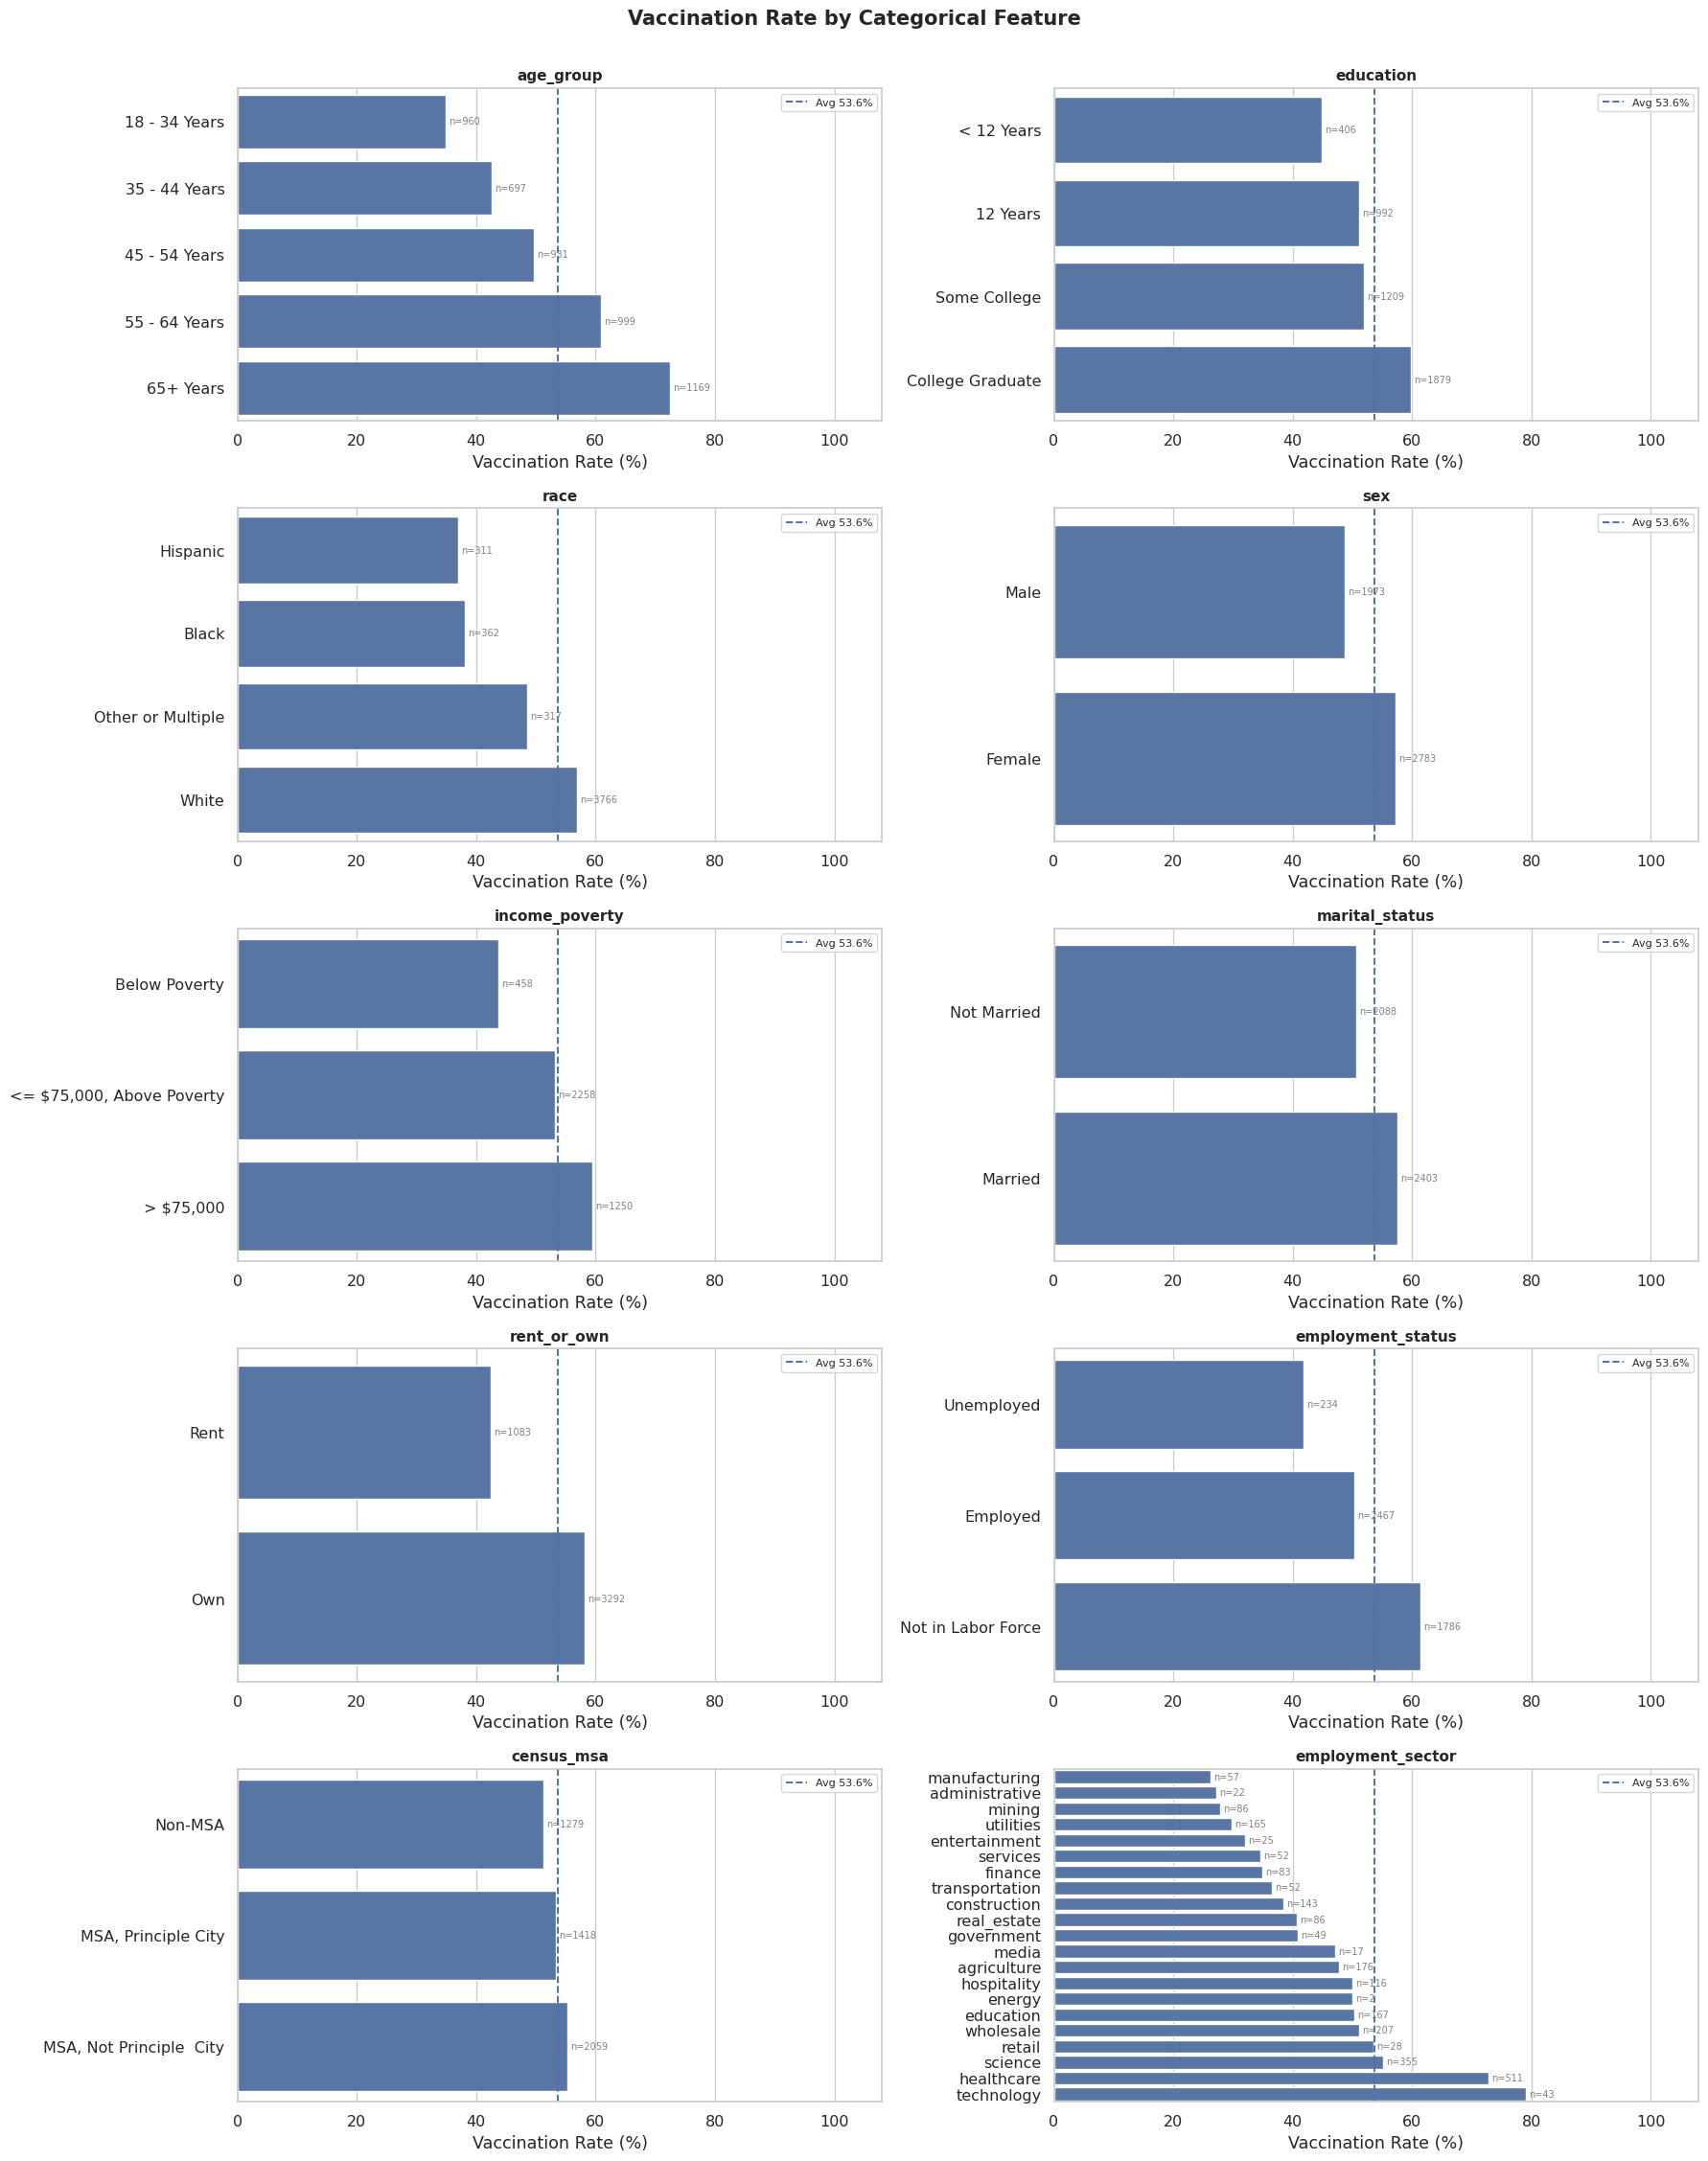

In [176]:
nrows_c = (len(cat_cols) + 1) // 2
fig, axes = plt.subplots(nrows_c, 2, figsize=(18, nrows_c * 4.5))
fig.suptitle("Vaccination Rate by Categorical Feature",
             fontsize=15, fontweight='bold', y=1.002)
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    ax  = axes_flat[i]
    grp = (df.groupby(col)[TARGET].agg(['mean', 'count']).reset_index()
             .sort_values('mean', ascending=True))
    grp['rate']  = grp['mean'] * 100
    grp['label'] = grp[col].astype(str).str[:28]

    sns.barplot(data=grp, y='label', x='rate', ax=ax)
    ax.axvline(avg_rate, linestyle='--', lw=1.4, label=f'Avg {avg_rate:.1f}%')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Vaccination Rate (%)')
    ax.set_ylabel('')
    ax.set_xlim(0, 108)
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(ax.patches, grp.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'n={int(row["count"])}', va='center', fontsize=7, color='gray')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
display(fig)
plt.close()

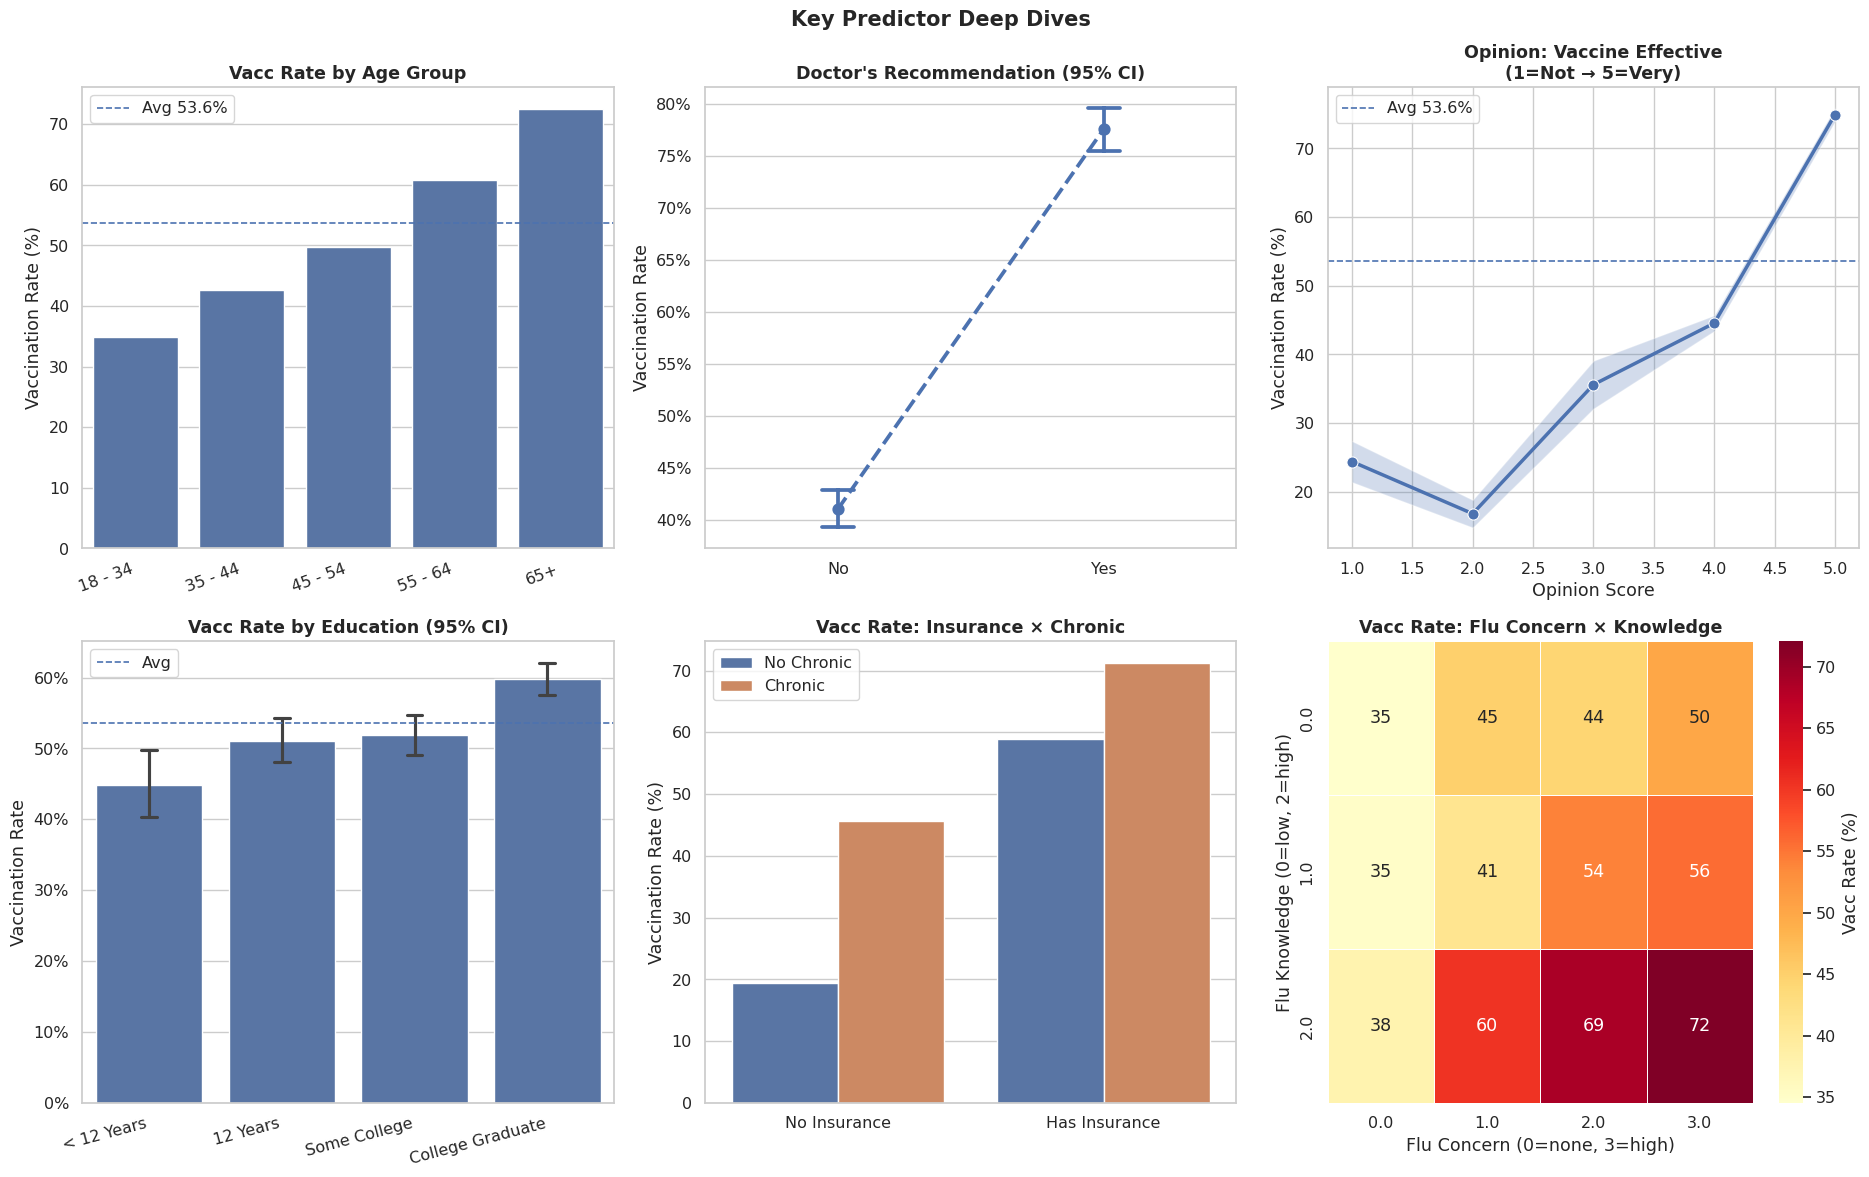

In [177]:
fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle("Key Predictor Deep Dives", fontsize=15, fontweight='bold')

# 5a Age group
age_order = ['18 - 34 Years','35 - 44 Years','45 - 54 Years','55 - 64 Years','65+ Years']
age_df = (df.groupby('age_group')[TARGET].mean() * 100).reindex(age_order).reset_index()
age_df.columns = ['age_group', 'rate']
sns.barplot(data=age_df, x='age_group', y='rate', ax=axes[0,0])
axes[0,0].axhline(avg_rate, linestyle='--', lw=1.2, label=f'Avg {avg_rate:.1f}%')
axes[0,0].set_xticklabels([a.replace(' Years','') for a in age_order], rotation=20, ha='right')
axes[0,0].set_title('Vacc Rate by Age Group', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Vaccination Rate (%)')
axes[0,0].legend()

# 5b Doctor recommendation
dr_df = df[df['doctor_recc_seasonal'].notna()].copy()
dr_df['Doctor Recc'] = dr_df['doctor_recc_seasonal'].map({0: 'No', 1: 'Yes'})
sns.pointplot(data=dr_df, x='Doctor Recc', y=TARGET, order=['No', 'Yes'],
              linestyles='--', capsize=0.12,
              errorbar='ci', ax=axes[0,1])
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[0,1].set_title("Doctor's Recommendation (95% CI)", fontweight='bold')
axes[0,1].set_ylabel('Vaccination Rate')
axes[0,1].set_xlabel('')

# 5c Opinion effectiveness
eff_df = df.groupby('opinion_seas_vacc_effective')[TARGET].agg(['mean','sem']).reset_index()
eff_df.columns = ['score', 'rate', 'sem']
eff_df['rate'] *= 100
eff_df['sem']  *= 100
axes[0,2].fill_between(eff_df['score'],
                       eff_df['rate'] - eff_df['sem'],
                       eff_df['rate'] + eff_df['sem'], alpha=0.25)
sns.lineplot(data=eff_df, x='score', y='rate', marker='o',
             markersize=8, linewidth=2.5, ax=axes[0,2])
axes[0,2].axhline(avg_rate, linestyle='--', lw=1.2, label=f'Avg {avg_rate:.1f}%')
axes[0,2].set_title('Opinion: Vaccine Effective\n(1=Not → 5=Very)', fontweight='bold')
axes[0,2].set_xlabel('Opinion Score')
axes[0,2].set_ylabel('Vaccination Rate (%)')
axes[0,2].legend()

# 5d Education
edu_order = ['< 12 Years','12 Years','Some College','College Graduate']
sns.barplot(data=df[df['education'].isin(edu_order)], x='education', y=TARGET,
            order=edu_order, errorbar='ci', capsize=0.12, ax=axes[1,0])
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[1,0].axhline(df[TARGET].mean(), linestyle='--', lw=1.2, label='Avg')
axes[1,0].set_xticklabels(edu_order, rotation=15, ha='right')
axes[1,0].set_title('Vacc Rate by Education (95% CI)', fontweight='bold')
axes[1,0].set_ylabel('Vaccination Rate')
axes[1,0].set_xlabel('')
axes[1,0].legend()

# 5e Insurance × Chronic
ic = df.groupby(['health_insurance','chronic_med_condition'])[TARGET].mean().reset_index()
ic.columns = ['insurance', 'chronic', 'rate']
ic['insurance'] = ic['insurance'].map({0: 'No Insurance', 1: 'Has Insurance'})
ic['chronic']   = ic['chronic'].map({0: 'No Chronic', 1: 'Chronic'})
ic['rate'] *= 100
sns.barplot(data=ic, x='insurance', y='rate', hue='chronic', ax=axes[1,1])
axes[1,1].set_title('Vacc Rate: Insurance × Chronic', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Vaccination Rate (%)')
axes[1,1].legend(title='')

# 5f Flu concern × knowledge heatmap
pivot = (df.groupby(['flu_concern','flu_knowledge'])[TARGET].mean()
           .reset_index()
           .pivot(index='flu_knowledge', columns='flu_concern', values=TARGET))
sns.heatmap(pivot * 100, ax=axes[1,2], cmap='YlOrRd',
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'Vacc Rate (%)'})
axes[1,2].set_title('Vacc Rate: Flu Concern × Knowledge', fontweight='bold')
axes[1,2].set_xlabel('Flu Concern (0=none, 3=high)')
axes[1,2].set_ylabel('Flu Knowledge (0=low, 2=high)')

plt.tight_layout()
display(fig)
plt.close()


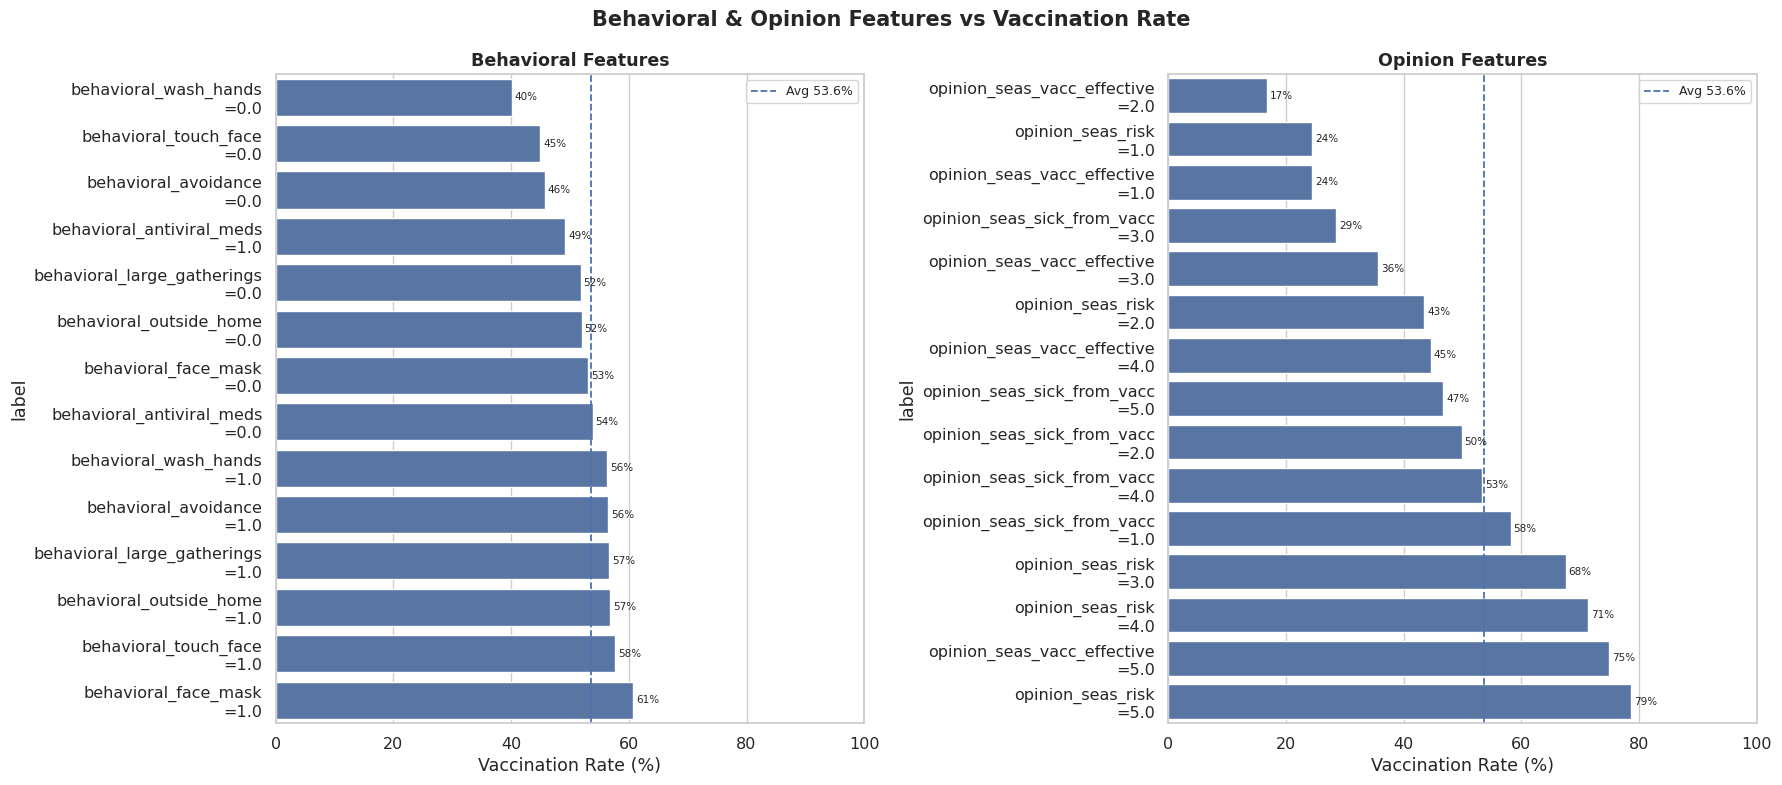

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Behavioral & Opinion Features vs Vaccination Rate",
             fontsize=15, fontweight='bold')

for ax, feat_list, title in [(axes[0], behav, 'Behavioral Features'),
                              (axes[1], opinion, 'Opinion Features')]:
    records = []
    for feat in feat_list:
        for k, v in (df.groupby(feat)[TARGET].mean() * 100).items():
            records.append({'label': f'{feat}\n={k}', 'rate': v})
    rd = pd.DataFrame(records).sort_values('rate', ascending=True)
    sns.barplot(data=rd, y='label', x='rate', ax=ax)
    ax.axvline(avg_rate, linestyle='--', lw=1.3, label=f'Avg {avg_rate:.1f}%')
    ax.set_xlabel('Vaccination Rate (%)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.legend(fontsize=9)
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                f'{w:.0f}%', va='center', fontsize=7.5)

plt.tight_layout()
display(fig)
plt.close()

**Dataset Pre-processing**

In [179]:
df = pd.read_csv('dataset_A_training.csv')
df = df.drop(columns=['respondent_id', 'employment_sector'])

X = df.drop(columns=['seasonal_vaccine'])
y = df['seasonal_vaccine']

print("X shape:", X.shape)
print(y.value_counts())

X shape: (4756, 28)
seasonal_vaccine
1    2551
0    2205
Name: count, dtype: int64


In [180]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

health_insurance               1925
income_poverty                  790
rent_or_own                     381
doctor_recc_seasonal            321
education                       270
employment_status               269
marital_status                  265
chronic_med_condition           188
child_under_6_months            152
health_worker                   149
opinion_seas_risk               102
opinion_seas_sick_from_vacc     101
opinion_seas_vacc_effective      94
household_adults                 44
household_children               44
behavioral_avoidance             32
flu_knowledge                    23
behavioral_touch_face            19
behavioral_antiviral_meds        14
flu_concern                      12
behavioral_large_gatherings       9
behavioral_outside_home           9
behavioral_wash_hands             8
behavioral_face_mask              3
dtype: int64


In [181]:
num_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
nominal_cols = ['race', 'sex', 'marital_status', 'rent_or_own',
                'employment_status', 'census_msa']
ordinal_cols = ['age_group', 'education', 'income_poverty']
cat_cols     = nominal_cols + ordinal_cols

print("Numeric :", num_cols)
print("Nominal :", nominal_cols)
print("Ordinal :", ordinal_cols)

Numeric : ['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Nominal : ['race', 'sex', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa']
Ordinal : ['age_group', 'education', 'income_poverty']


In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3804, 28)
Test : (952, 28)


**Data Imputation**

In [183]:
# numeric median
num_imputer       = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

# categorical most frequent (mode)
cat_imputer       = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

print("Missing train:", X_train.isnull().sum().sum())
print("Missing test :", X_test.isnull().sum().sum())

Missing train: 0
Missing test : 0


**Ordinal Encoding**

In [184]:
age_map    = {'18 - 34 Years': 0, '35 - 44 Years': 1, '45 - 54 Years': 2,
              '55 - 64 Years': 3, '65+ Years': 4}
edu_map    = {'< 12 Years': 0, '12 Years': 1,
              'Some College': 2, 'College Graduate': 3}
income_map = {'Below Poverty': 0, '<= $75,000, Above Poverty': 1, '> $75,000': 2}

for col, mapping in [('age_group',      age_map),
                     ('education',      edu_map),
                     ('income_poverty', income_map)]:
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)

print("Done")

Done


**Nominal label Encoding**

In [185]:
le_dict = {}
for col in nominal_cols:
    le            = LabelEncoder()
    X_train[col]  = le.fit_transform(X_train[col].astype(str))
    le_dict[col]  = le
    X_test[col]   = X_test[col].astype(str).apply(
        lambda v: le.transform([v])[0] if v in le.classes_ else -1)

print("Done")

Done


**Scaling**

In [186]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)

Train: (3804, 28)
Test : (952, 28)


**Logistic Regression**

In [187]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [188]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print()
print(classification_report(y_test, y_pred,
      target_names=['No Vaccine', 'Vaccinated']))

Accuracy: 0.771
ROC-AUC : 0.8447

              precision    recall  f1-score   support

  No Vaccine       0.75      0.76      0.75       441
  Vaccinated       0.79      0.78      0.79       511

    accuracy                           0.77       952
   macro avg       0.77      0.77      0.77       952
weighted avg       0.77      0.77      0.77       952



**Confusion Matrix**

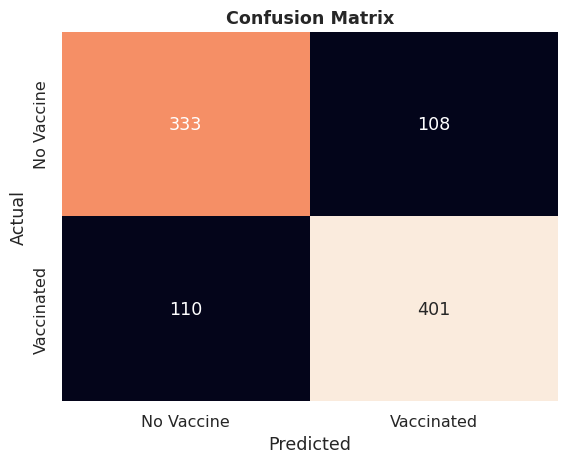

In [189]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=['No Vaccine', 'Vaccinated'],
            yticklabels=['No Vaccine', 'Vaccinated'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**ROC Curve**

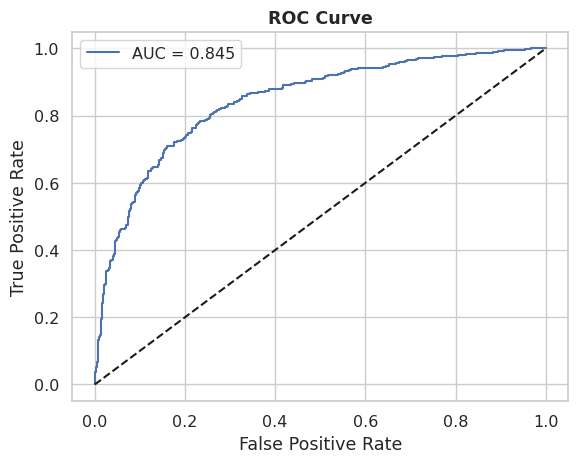

In [190]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend()
plt.show()

**Cross Validation**

In [191]:
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
acc = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='accuracy')
f1  = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='f1')

print("ROC-AUC  : {:.4f} ± {:.4f}".format(auc.mean(), auc.std()))
print("Accuracy : {:.4f} ± {:.4f}".format(acc.mean(), acc.std()))
print("F1       : {:.4f} ± {:.4f}".format(f1.mean(), f1.std()))

ROC-AUC  : 0.8425 ± 0.0084
Accuracy : 0.7723 ± 0.0100
F1       : 0.7886 ± 0.0105


**Feature Coeffecients**

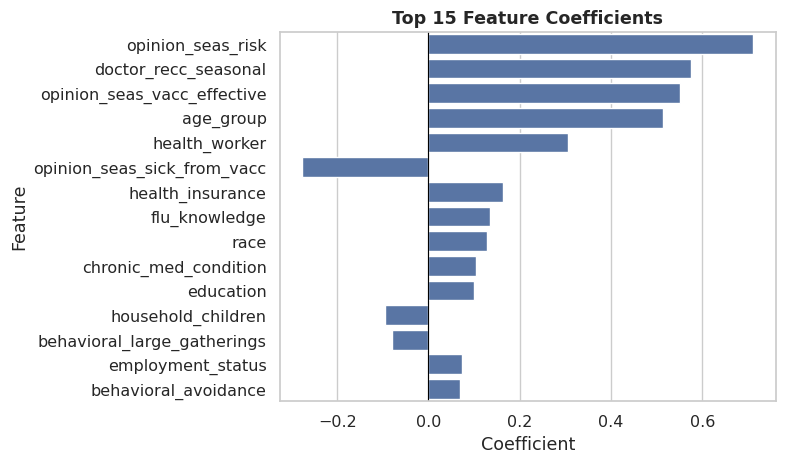

In [192]:
coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 15 Feature Coefficients', fontweight='bold')
plt.show()

In [205]:
df_test = pd.read_csv('dataset_A_testing.csv')
print("Test shape:", df_test.shape)

Test shape: (4749, 30)


In [206]:
test_ids = df_test['respondent_id'].copy()

df_test  = df_test.drop(columns=['respondent_id', 'employment_sector'])
print("Test shape after drop:", df_test.shape)
print("IDs saved:", len(test_ids))

Test shape after drop: (4749, 28)
IDs saved: 4749


In [207]:
df_test[num_cols] = num_imputer.transform(df_test[num_cols])
df_test[cat_cols] = cat_imputer.transform(df_test[cat_cols])

print("Missing after impute:", df_test.isnull().sum().sum())

Missing after impute: 0


In [208]:
for col, mapping in [('age_group',      age_map),
                     ('education',      edu_map),
                     ('income_poverty', income_map)]:
    df_test[col] = df_test[col].map(mapping)

print("Done")

Done


In [209]:
for col in nominal_cols:
    le = le_dict[col]
    df_test[col] = df_test[col].astype(str).apply(
        lambda v: le.transform([v])[0] if v in le.classes_ else -1)

print("Done")

Done


In [210]:
df_test_scaled = scaler.transform(df_test)
print("Scaled shape:", df_test_scaled.shape)

Scaled shape: (4749, 28)


In [211]:
y_test_prob = lr.predict_proba(df_test_scaled)[:, 1]
print("Predictions done")
print("Sample:", y_test_prob[:5])

Predictions done
Sample: [0.42872858 0.7763116  0.83403723 0.83952822 0.18490592]


In [214]:
y_test_pred = lr.predict(df_test_scaled)

submission = pd.DataFrame({
    'respondent_id'   : test_ids,
    'seasonal_vaccine': y_test_pred
})

submission.to_csv('submission.csv', index=False)
print("Done")
print(submission.head(10))

Done
   respondent_id  seasonal_vaccine
0           4757                 0
1           4758                 1
2           4759                 1
3           4760                 1
4           4761                 0
5           4762                 1
6           4763                 1
7           4764                 1
8           4765                 1
9           4766                 1
